In [20]:
import os
import sys
#pointing python to project root
sys.path.insert(0, os.path.abspath(".."))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text
from ingestion.db import get_engine
import warnings

warnings.filterwarnings("ignore")

engine =  get_engine()
df = pd.read_sql("SELECT * FROM weather_readings ORDER BY timestamp ASC", engine)
print(f"Loaded {len(df)} rows")

df.head()


Loaded 744 rows


,id,timestamp,station_id,temperature_2m,shortwave_radiation,windspeed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,rain,cloud_cover,soil_temperature_7_to_28cm,soil_moisture_7_to_28cm
0,1,2024-01-01 00:00:00,plateau_jos,17.0,0.0,9.4,88.0,14.8,36.0,0.0,0.0,22.8,0.28
1,2,2024-01-01 01:00:00,plateau_jos,17.7,0.0,8.3,90.0,11.9,34.0,0.0,0.0,22.7,0.28
2,3,2024-01-01 02:00:00,plateau_jos,17.9,0.0,8.4,80.0,11.5,33.0,0.0,0.0,22.5,0.28
3,4,2024-01-01 03:00:00,plateau_jos,17.8,0.0,8.7,85.0,10.8,33.0,0.0,0.0,22.3,0.28
4,5,2024-01-01 04:00:00,plateau_jos,17.0,0.0,9.5,81.0,11.9,35.0,0.0,0.0,22.1,0.28


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          744 non-null    int64         
 1   timestamp                   744 non-null    datetime64[ns]
 2   station_id                  744 non-null    object        
 3   temperature_2m              744 non-null    float64       
 4   shortwave_radiation         744 non-null    float64       
 5   windspeed_10m               744 non-null    float64       
 6   wind_direction_10m          744 non-null    float64       
 7   wind_gusts_10m              744 non-null    float64       
 8   relative_humidity_2m        744 non-null    float64       
 9   rain                        744 non-null    float64       
 10  cloud_cover                 744 non-null    float64       
 11  soil_temperature_7_to_28cm  744 non-null    float64       

In [22]:
df.describe()

,id,timestamp,temperature_2m,shortwave_radiation,windspeed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,rain,cloud_cover,soil_temperature_7_to_28cm,soil_moisture_7_to_28cm
count,744.000000,744,744.000000,744.000000,744.00000,744.000000,744.000000,744.000000,744.0,744.000000,744.000000,744.000000
mean,372.500000,2024-01-16 11:29:59.999999744,19.986290,265.766129,10.71129,67.786290,20.952285,22.350806,0.0,16.610215,21.811559,0.278559
min,1.000000,2024-01-01 00:00:00,10.600000,0.000000,1.10000,15.000000,3.600000,8.000000,0.0,0.000000,19.400000,0.277000
25%,186.750000,2024-01-08 17:45:00,15.675000,0.000000,9.00000,53.000000,14.800000,16.000000,0.0,0.000000,21.100000,0.278000
50%,372.500000,2024-01-16 11:30:00,18.900000,2.000000,11.00000,65.000000,19.100000,22.000000,0.0,0.000000,21.800000,0.279000
75%,558.250000,2024-01-24 05:15:00,24.700000,584.250000,12.40000,75.000000,27.700000,28.000000,0.0,10.250000,22.500000,0.279000
max,744.000000,2024-01-31 23:00:00,30.200000,965.000000,18.50000,360.000000,40.700000,45.000000,0.0,100.000000,23.900000,0.280000
std,214.918589,NaN,5.174414,347.754692,2.59034,31.023089,7.591927,7.723994,0.0,32.458296,1.023453,0.000895


In [12]:
print("shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

shape: (744, 13)

Missing values:
 id                            0
timestamp                     0
station_id                    0
temperature_2m                0
shortwave_radiation           0
windspeed_10m                 0
wind_direction_10m            0
wind_gusts_10m                0
relative_humidity_2m          0
rain                          0
cloud_cover                   0
soil_temperature_7_to_28cm    0
soil_moisture_7_to_28cm       0
dtype: int64


In [13]:
#fixin datatypes
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["station_id"] = df["station_id"].astype(str)

In [15]:
sensor_cols = [
    "temperature_2m", "shortwave_radiation", "windspeed_10m",
    "wind_direction_10m", "wind_gusts_10m", "relative_humidity_2m",
    "rain", "cloud_cover", "soil_temperature_7_to_28cm", "soil_moisture_7_to_28cm"
]

for col in sensor_cols:
    df[f"{col}_missing"] = df[col].isnull().astype(int)


## Removing outliers

In [16]:
bounds = {
    "temperature_2m":             (-10, 50),
    "shortwave_radiation":        (0, 1200),
    "windspeed_10m":              (0, 150),
    "wind_gusts_10m":             (0, 200),
    "relative_humidity_2m":       (0, 100),
    "rain":                       (0, 200),
    "cloud_cover":                (0, 100),
    "soil_temperature_7_to_28cm": (0, 60),
    "soil_moisture_7_to_28cm":    (0, 1.0),
}

for col, (low, high) in bounds.items():
    if col in df.columns:
        mask = (df[col] < low) | (df[col] > high)
        if mask.sum() > 0:
            print(f"{col}: {mask.sum()} outliers removed")
            df.loc[mask, col] = np.nan



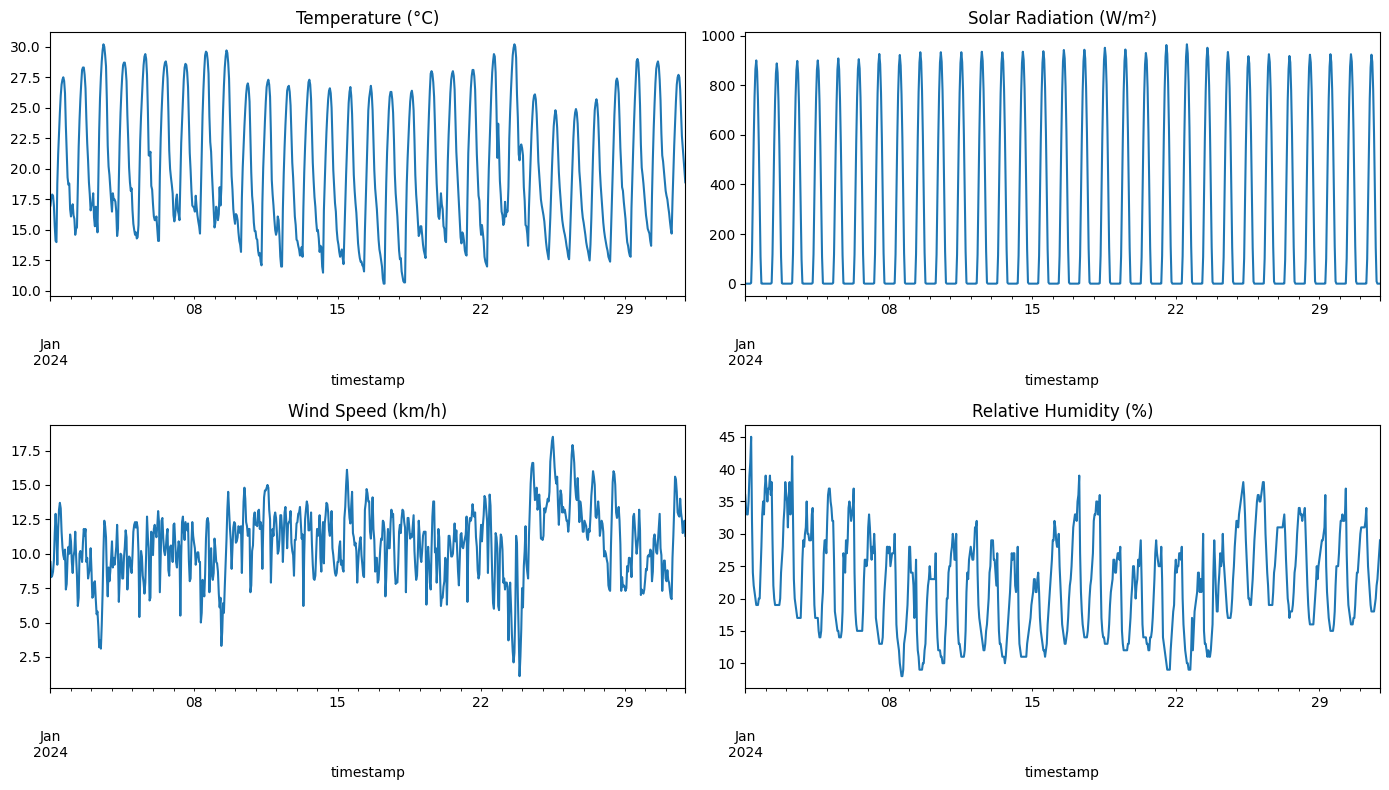

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

df.plot(x="timestamp", y="temperature_2m", ax=axes[0,0], title="Temperature (°C)", legend=False)
df.plot(x="timestamp", y="shortwave_radiation", ax=axes[0,1], title="Solar Radiation (W/m²)", legend=False)
df.plot(x="timestamp", y="windspeed_10m", ax=axes[1,0], title="Wind Speed (km/h)", legend=False)
df.plot(x="timestamp", y="relative_humidity_2m", ax=axes[1,1], title="Relative Humidity (%)", legend=False)

plt.tight_layout()
plt.show()

In [19]:
df.head()

,id,timestamp,station_id,temperature_2m,shortwave_radiation,windspeed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,rain,...,temperature_2m_missing,shortwave_radiation_missing,windspeed_10m_missing,wind_direction_10m_missing,wind_gusts_10m_missing,relative_humidity_2m_missing,rain_missing,cloud_cover_missing,soil_temperature_7_to_28cm_missing,soil_moisture_7_to_28cm_missing
0,1,2024-01-01 00:00:00,plateau_jos,17.0,0.0,9.4,88.0,14.8,36.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,2,2024-01-01 01:00:00,plateau_jos,17.7,0.0,8.3,90.0,11.9,34.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,3,2024-01-01 02:00:00,plateau_jos,17.9,0.0,8.4,80.0,11.5,33.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,4,2024-01-01 03:00:00,plateau_jos,17.8,0.0,8.7,85.0,10.8,33.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,5,2024-01-01 04:00:00,plateau_jos,17.0,0.0,9.5,81.0,11.9,35.0,0.0,...,0,0,0,0,0,0,0,0,0,0
